泰坦尼克号乘客生还预测 - 决策树案例 (本地 CSV)

【数据形状】(891, 12)
【列名】['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

二、分析数据

【前5行数据】
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7632\954051308.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7632\954051308.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

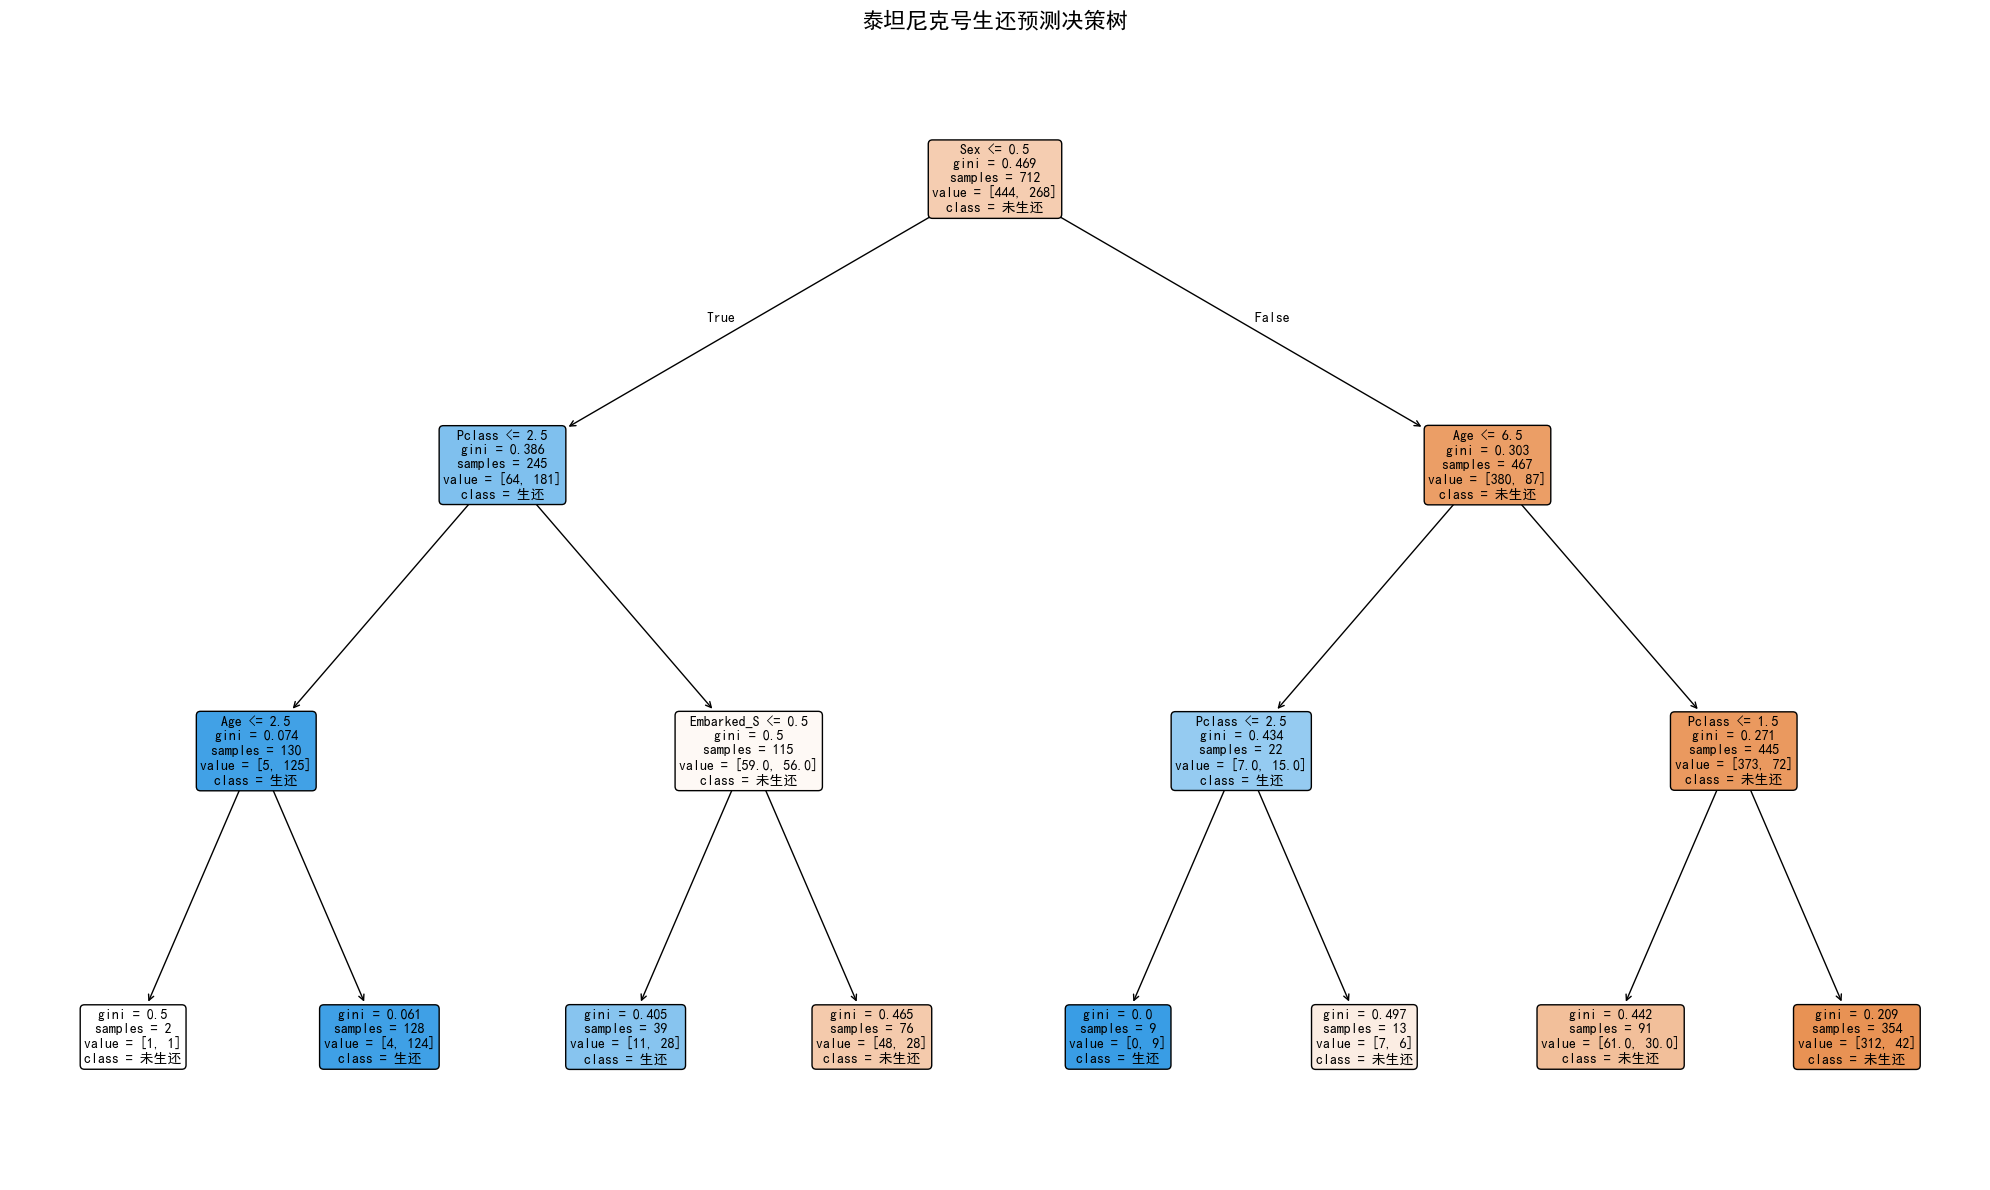

✓ 决策树已保存为 titanic_tree.png

六、特征重要度

【特征重要度排名】
   feature  importance
       Sex    0.638590
    Pclass    0.240976
       Age    0.079439
Embarked_S    0.040995
Embarked_Q    0.000000


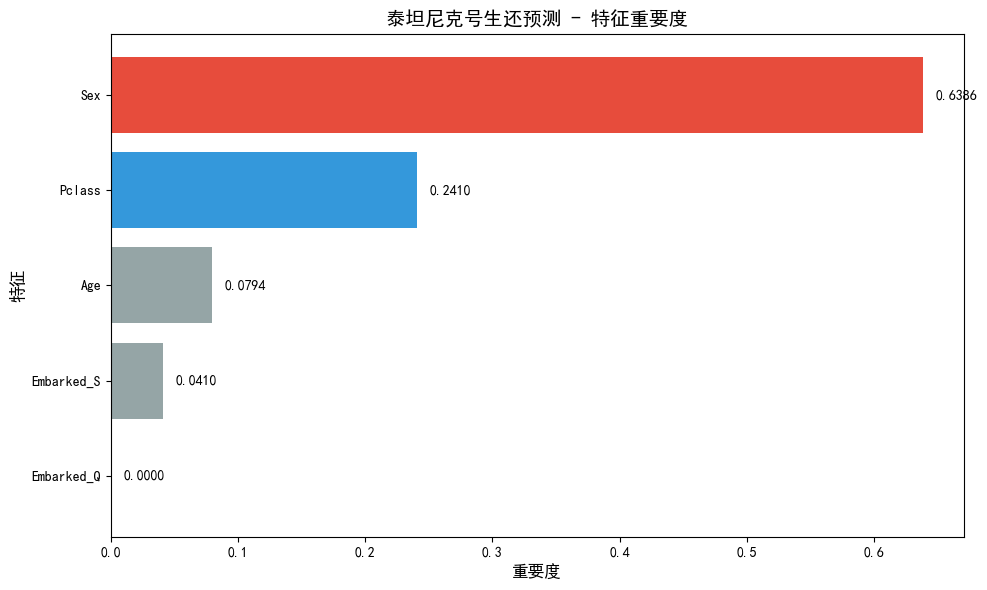

✓ 特征重要度图已保存为 feature_importance.png

七、模型优化 - 网格搜索
【最优参数】{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
【最优交叉验证准确率】0.8273
【最优模型测试集准确率】0.7933

案例完成！


In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("泰坦尼克号乘客生还预测 - 决策树案例 (本地 CSV)")
print("=" * 60)

# ==================== 一、读入数据 ====================
# 直接读取当前目录下的 titanic.csv
# 如果文件在其他文件夹，请修改路径，例如：data = pd.read_csv("data/titanic.csv")
data = pd.read_csv("titanic.csv")

print(f"\n【数据形状】{data.shape}")
print(f"【列名】{list(data.columns)}")

# ==================== 二、分析数据 ====================
print("\n" + "=" * 60)
print("二、分析数据")
print("=" * 60)

print("\n【前5行数据】")
print(data.head())

print("\n【数据信息】")
print(data.info())

print("\n【数值型特征统计】")
print(data.describe())

print("\n【Embarked取值分布】")
print(data['Embarked'].value_counts())

# ==================== 三、处理数据 ====================
print("\n" + "=" * 60)
print("三、处理数据")
print("=" * 60)

# 1. 填充缺失值
data['Age'].fillna(data['Age'].median(), inplace=True)
print("✓ Age列缺失值已用中位数填充")

data['Embarked'].fillna('S', inplace=True)
print("✓ Embarked列缺失值已用'S'填充")

# Fare 也可能有缺失（极少），做同样处理
data['Fare'].fillna(data['Fare'].median(), inplace=True)
print("✓ Fare列缺失值已用中位数填充")

# 2. 编码转换
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})
print("✓ Sex列已转换为数值编码 (female=0, male=1)")

# Embarked 独热编码 (只生成 Q 和 S 两列，因为 C 作为基准)
embarked_d = pd.get_dummies(data['Embarked'], prefix='Embarked', drop_first=True)
data = pd.concat([data, embarked_d], axis=1)
print(f"✓ Embarked已独热编码，生成列: {list(embarked_d.columns)}")

# 3. 选择特征 (与教程一致)
feature_cols = ['Pclass', 'Sex', 'Age', 'Embarked_Q', 'Embarked_S']
X = data[feature_cols]
y = data['Survived']

print(f"\n【特征矩阵X】形状: {X.shape}")
print(f"【目标向量y】形状: {y.shape}")
print(f"【使用的特征】{feature_cols}")

# ==================== 四、训练和选择模型 ====================
print("\n" + "=" * 60)
print("四、训练和选择模型")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✓ 训练集: {X_train.shape[0]} 样本")
print(f"✓ 测试集: {X_test.shape[0]} 样本")

treeclf = DecisionTreeClassifier(max_depth=3, random_state=1)
treeclf.fit(X_train, y_train)
print("✓ 模型训练完成")

y_pred = treeclf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n【测试集准确率】{accuracy:.4f}")

cv_scores = cross_val_score(treeclf, X, y, cv=5)
print(f"【5折交叉验证准确率】{cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n【分类报告】")
print(classification_report(y_test, y_pred, target_names=['未生还', '生还']))

# ==================== 五、可视化决策树 ====================
print("\n" + "=" * 60)
print("五、可视化决策树")
print("=" * 60)

try:
    import graphviz
    dot_data = export_graphviz(
        treeclf, 
        out_file=None,
        feature_names=feature_cols,
        class_names=['未生还', '生还'],
        filled=True, 
        rounded=True,
        special_characters=True
    )
    graph = graphviz.Source(dot_data)
    graph.render("titanic_tree", format='png', cleanup=True)
    print("✓ 决策树已保存为 titanic_tree.png")
except ImportError:
    print("⚠ 未安装graphviz，使用matplotlib绘制树结构")
    from sklearn.tree import plot_tree
    plt.figure(figsize=(20, 12))
    plot_tree(treeclf, 
              feature_names=feature_cols,
              class_names=['未生还', '生还'],
              filled=True, 
              rounded=True,
              fontsize=10)
    plt.title("泰坦尼克号生还预测决策树", fontsize=16)
    plt.tight_layout()
    plt.savefig("titanic_tree.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ 决策树已保存为 titanic_tree.png")

# ==================== 六、特征重要度 ====================
print("\n" + "=" * 60)
print("六、特征重要度")
print("=" * 60)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': treeclf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n【特征重要度排名】")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i == 0 else '#3498db' if i == 1 else '#95a5a6' 
          for i in range(len(importance_df))]
bars = plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('重要度', fontsize=12)
plt.ylabel('特征', fontsize=12)
plt.title('泰坦尼克号生还预测 - 特征重要度', fontsize=14)
plt.gca().invert_yaxis()

for bar, val in zip(bars, importance_df['importance']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ 特征重要度图已保存为 feature_importance.png")

# ==================== 七、模型优化 ====================
print("\n" + "=" * 60)
print("七、模型优化 - 网格搜索")
print("=" * 60)

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"【最优参数】{grid_search.best_params_}")
print(f"【最优交叉验证准确率】{grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"【最优模型测试集准确率】{best_accuracy:.4f}")

print("\n" + "=" * 60)
print("案例完成！")
print("=" * 60)